In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
import os
import glob
import calendar


Eastern East Africa NCEP

In [3]:
eea_ncep_path = '/content/drive/MyDrive/capstone_data/netCDF/eastern_east_africa_NCEP_merged.nc'
eea_ncep = xr.open_dataset(eea_ncep_path)

eea_ncep_slice = eea_ncep["precip"]
eea_ncep = eea_ncep.to_dataframe().reset_index()

eea_ncep

,lead_time,time,M,latitude,longitude,predicted_precip,precip
0,0.5,1982-01-01,1.0,-3.5,38.0,3.40875,11.374672
1,0.5,1982-01-01,1.0,-3.5,38.5,3.40875,12.559185
2,0.5,1982-01-01,1.0,-3.5,39.0,2.29554,12.911411
3,0.5,1982-01-01,1.0,-3.5,39.5,2.29554,11.975130
4,0.5,1982-01-01,1.0,-3.5,40.0,NaN,NaN
...,...,...,...,...,...,...,...
52254715,9.5,2024-12-01,24.0,8.0,47.5,NaN,NaN
52254716,9.5,2024-12-01,24.0,8.0,48.0,NaN,NaN
52254717,9.5,2024-12-01,24.0,8.0,48.5,NaN,NaN
52254718,9.5,2024-12-01,24.0,8.0,49.0,NaN,NaN


WET AND DRY YEARS FOR 2024 (LEAD 0, 5, 11)


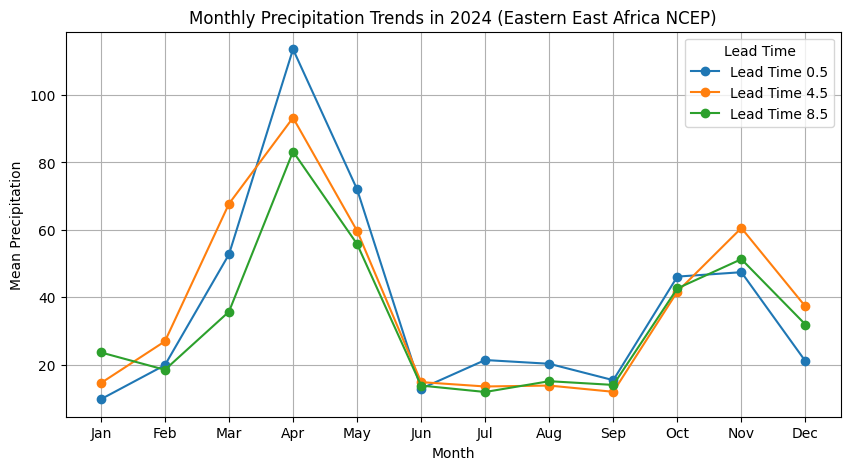

Wettest Months (Highest Precipitation) per Lead Time:
lead_time
0.5    4 (April)
4.5    4 (April)
8.5    4 (April)
dtype: object

Driest Months (Lowest Precipitation) per Lead Time:
lead_time
0.5      1 (January)
4.5    9 (September)
8.5         7 (July)
dtype: object


In [4]:
# lead time
lead_times = [0.5, 4.5, 8.5]
eea_ncep['time'] = pd.to_datetime(eea_ncep['time'])
eea_ncep['predicted_precip'] = eea_ncep['predicted_precip'] * 30

# 2024
eea_ncep_2024 = eea_ncep[eea_ncep['time'].dt.year == 2024].copy()

# lead time data / year
filtered_data = eea_ncep_2024[eea_ncep_2024['lead_time'].isin(lead_times)].copy()

#  extract month
filtered_data.loc[:, 'month'] = filtered_data['time'].dt.month

# mean precip for month for each lead time
monthly_precip = filtered_data.groupby(['lead_time', 'month'])['predicted_precip'].mean().unstack(level=0)

plt.figure(figsize=(10, 5))

for lead_time in lead_times:
    if lead_time in monthly_precip.columns:
        plt.plot(monthly_precip.index, monthly_precip[lead_time], marker='o', label=f'Lead Time {lead_time}')

plt.xlabel('Month')
plt.ylabel('Mean Precipitation')
plt.title('Monthly Precipitation Trends in 2024 (Eastern East Africa NCEP)')
plt.xticks(ticks=range(1, 13), labels=[
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title="Lead Time")
plt.grid(True)
plt.show()

# wettest and driest month
wettest_months = monthly_precip.idxmax()
driest_months = monthly_precip.idxmin()

# map month numbers to names
month_names = {
    1: "January", 2: "February", 3: "March", 4: "April", 5: "May", 6: "June",
    7: "July", 8: "August", 9: "September", 10: "October", 11: "November", 12: "December"
}

# numerical months to named months
wettest_months_named = wettest_months.map(lambda x: f"{x} ({month_names[x]})")
driest_months_named = driest_months.map(lambda x: f"{x} ({month_names[x]})")

print("Wettest Months (Highest Precipitation) per Lead Time:")
print(wettest_months_named)
print("\nDriest Months (Lowest Precipitation) per Lead Time:")
print(driest_months_named)


Key Observations:
Peak Rainfall in April (Wettest Month)

All three lead times show a sharp increase in precipitation, peaking around April with values exceeding 120 mm for some lead times.
This suggests April is the wettest month in the region for 2024.
Lowest Precipitation in June (Driest Month)

June has the lowest precipitation across all three lead times, dropping close to zero.
This indicates that June is likely the driest month.
Two Rainy Seasons (Bimodal Rainfall Pattern?)

Primary peak in April (long rains).
Secondary increase in October-November (short rains).
This suggests that the region experiences two main rainy periods.
Lead Time Variation:

Predictions at different lead times (0.5, 4.5, 9.5 months) follow a similar trend but with some variations in magnitude.
The model retains consistency across forecasts, meaning precipitation trends are predictable.


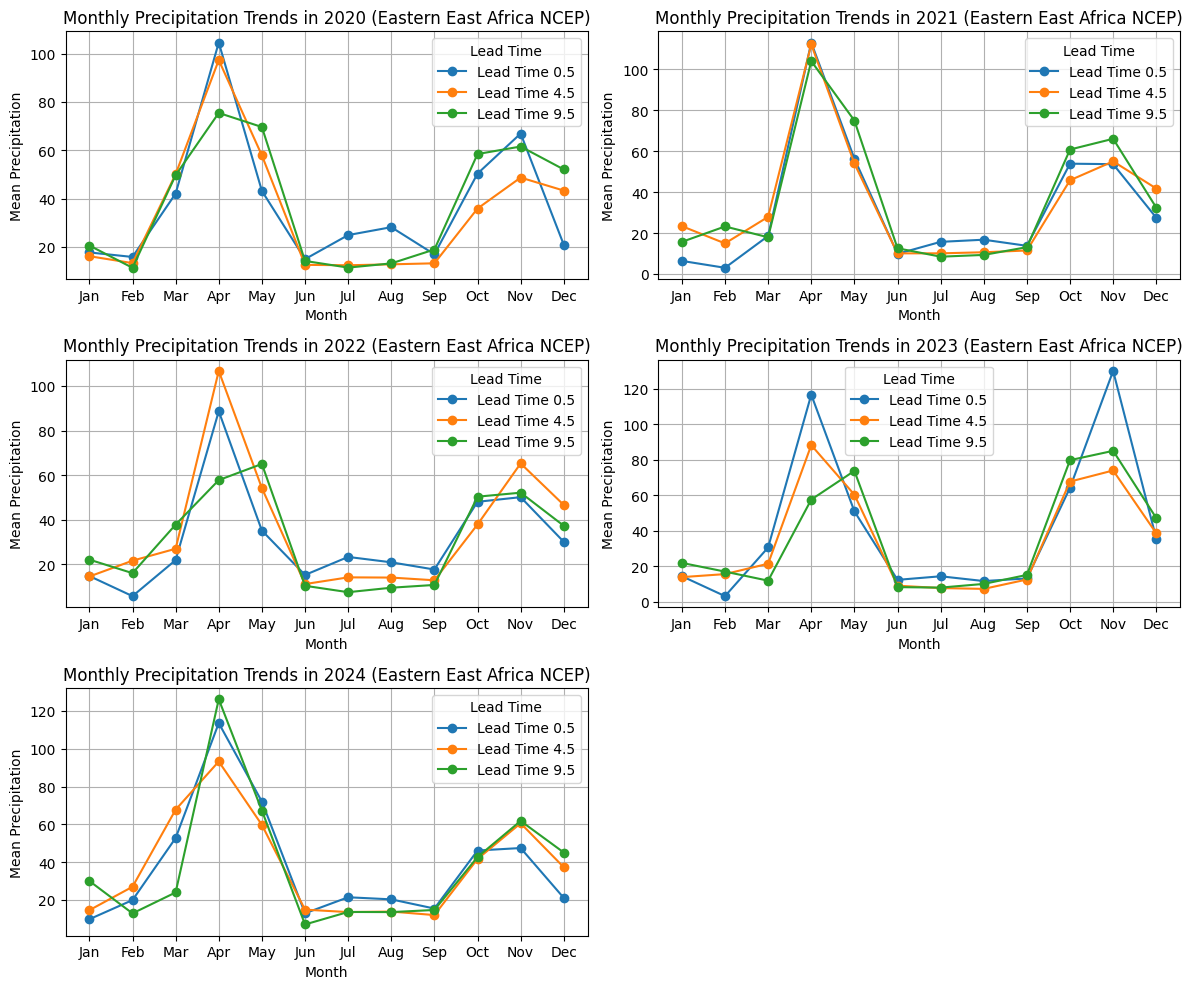

Comparison of Wettest Months (Highest Precipitation) across 2020-2024:
                2020       2021       2022           2023       2024
lead_time                                                           
0.5        4 (April)  4 (April)  4 (April)  11 (November)  4 (April)
4.5        4 (April)  4 (April)  4 (April)      4 (April)  4 (April)
9.5        4 (April)  4 (April)    5 (May)  11 (November)  4 (April)

Comparison of Driest Months (Lowest Precipitation) across 2020-2024:
                   2020          2021          2022          2023  \
lead_time                                                           
0.5            6 (June)  2 (February)  2 (February)  2 (February)   
4.5            7 (July)      6 (June)      6 (June)    8 (August)   
9.5        2 (February)      7 (July)      7 (July)      7 (July)   

                    2024  
lead_time                 
0.5          1 (January)  
4.5        9 (September)  
9.5             6 (June)  


<ipython-input-5-9a36934add8e>:59: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  wettest_months_named_df = wettest_months_df.applymap(lambda x: f"{x} ({month_names[x]})" if pd.notna(x) else "N/A")
<ipython-input-5-9a36934add8e>:60: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  driest_months_named_df = driest_months_df.applymap(lambda x: f"{x} ({month_names[x]})" if pd.notna(x) else "N/A")


In [5]:
years = [2020, 2021, 2022, 2023, 2024]
lead_times = [0.5, 4.5, 9.5]

# dictionary to store wettest and driest months for each year
wettest_months_dict = {}
driest_months_dict = {}

# plots
plt.figure(figsize=(12, 10))

for i, year in enumerate(years, 1):
    # year data
    eea_ncep_year = eea_ncep[eea_ncep['time'].dt.year == year].copy()

    # lead times
    filtered_data = eea_ncep_year[eea_ncep_year['lead_time'].isin(lead_times)].copy()

    # month extract
    filtered_data.loc[:, 'month'] = filtered_data['time'].dt.month

    # Aggregate mean precipitation per month for each lead time
    monthly_precip = filtered_data.groupby(['lead_time', 'month'])['predicted_precip'].mean().unstack(level=0)

    # Create subplot for the year
    plt.subplot(3, 2, i)
    for lead_time in lead_times:
        if lead_time in monthly_precip.columns:
            plt.plot(monthly_precip.index, monthly_precip[lead_time], marker='o', linestyle='-', label=f'Lead Time {lead_time}')

    # Formatting the plot
    plt.xlabel('Month')
    plt.ylabel('Mean Precipitation')
    plt.title(f'Monthly Precipitation Trends in {year} (Eastern East Africa NCEP)')
    plt.xticks(ticks=range(1, 13), labels=[
        'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    plt.legend(title="Lead Time")
    plt.grid(True)

    # Store wettest and driest months for the year
    wettest_months_dict[year] = monthly_precip.idxmax()
    driest_months_dict[year] = monthly_precip.idxmin()

# Adjust layout and show plots
plt.tight_layout()
plt.show()

# Convert dictionaries to DataFrames for better comparison
wettest_months_df = pd.DataFrame(wettest_months_dict)
driest_months_df = pd.DataFrame(driest_months_dict)

# map month numbers to names
month_names = {
    1: "January", 2: "February", 3: "March", 4: "April", 5: "May", 6: "June",
    7: "July", 8: "August", 9: "September", 10: "October", 11: "November", 12: "December"
}

# Convert numerical months to named months for both wettest and driest months
wettest_months_named_df = wettest_months_df.applymap(lambda x: f"{x} ({month_names[x]})" if pd.notna(x) else "N/A")
driest_months_named_df = driest_months_df.applymap(lambda x: f"{x} ({month_names[x]})" if pd.notna(x) else "N/A")

# Print results with month names for comparison
print("Comparison of Wettest Months (Highest Precipitation) across 2020-2024:")
print(wettest_months_named_df)
print("\nComparison of Driest Months (Lowest Precipitation) across 2020-2024:")
print(driest_months_named_df)

TAKING ONLY APRIL AND NOVEMBER FOR YEARS 2010 TO 2024


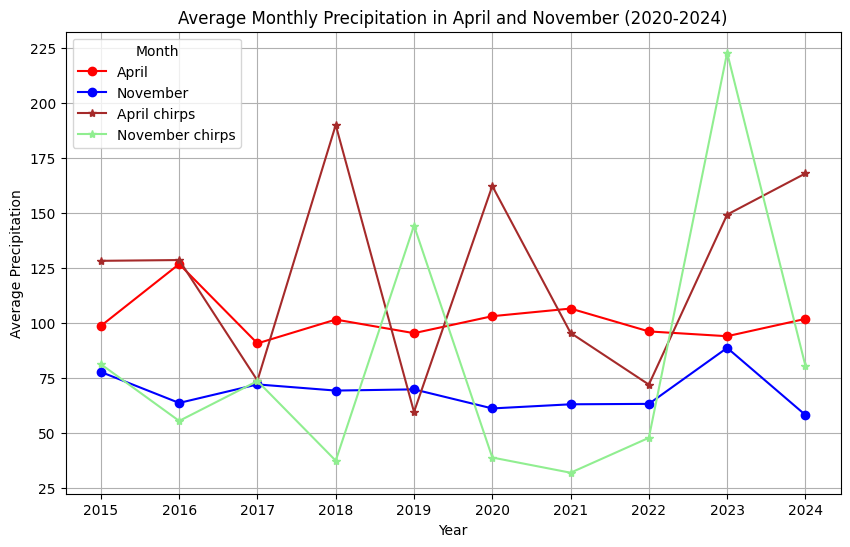

In [6]:
years = [2015, 2016,2017,2018, 2019, 2020, 2021, 2022, 2023, 2024]
months_of_interest = [4, 11]  # April and November

# Filter data for the selected years and months
filtered_data = eea_ncep[eea_ncep['time'].dt.year.isin(years) & eea_ncep['time'].dt.month.isin(months_of_interest)].copy()

# Extract year and month
filtered_data['year'] = filtered_data['time'].dt.year
filtered_data['month'] = filtered_data['time'].dt.month

# Compute average precipitation per month for each year
monthly_avg_precip = filtered_data.groupby(['year', 'month'])['predicted_precip'].mean().unstack(level=1)
monthly_avg_precip_act = filtered_data.groupby(['year', 'month'])['precip'].mean().unstack(level=1)

# Plot the results
plt.figure(figsize=(10, 6))

# predicted
plt.plot(monthly_avg_precip.index, monthly_avg_precip[4], marker='o', linestyle='-', label='April', color='red')
plt.plot(monthly_avg_precip.index, monthly_avg_precip[11], marker='o', linestyle='-', label='November', color='blue')

# actual
plt.plot(monthly_avg_precip_act.index, monthly_avg_precip_act[4], marker='*', linestyle='-', label='April chirps', color='brown')
plt.plot(monthly_avg_precip_act.index, monthly_avg_precip_act[11], marker='*', linestyle='-', label='November chirps', color='lightgreen')

plt.xlabel('Year')
plt.ylabel('Average Precipitation')
plt.title('Average Monthly Precipitation in April and November (2020-2024)')
plt.xticks(years)
plt.legend(title="Month")
plt.grid(True)

plt.show()


Eastern East Africa NASA




In [7]:
eea_nasa_path = '/content/drive/MyDrive/capstone_data/netCDF/eastern_east_africa_NASA_merged.nc'
eea_nasa = xr.open_dataset(eea_nasa_path)

eea_nasa_slice = eea_nasa["precip"]
eea_nasa = eea_nasa.to_dataframe().reset_index()

eea_nasa

,lead_time,time,M,latitude,longitude,predicted_precip,precip
0,0.5,1982-01-01,1.0,-3.5,38.0,1.802491,11.374672
1,0.5,1982-01-01,1.0,-3.5,38.5,1.802491,12.559185
2,0.5,1982-01-01,1.0,-3.5,39.0,1.420417,12.911411
3,0.5,1982-01-01,1.0,-3.5,39.5,1.420417,11.975130
4,0.5,1982-01-01,1.0,-3.5,40.0,NaN,NaN
...,...,...,...,...,...,...,...
26749435,8.5,2024-12-01,10.0,8.0,47.5,0.283359,2.742029
26749436,8.5,2024-12-01,10.0,8.0,48.0,0.211012,0.612805
26749437,8.5,2024-12-01,10.0,8.0,48.5,0.211012,0.271429
26749438,8.5,2024-12-01,10.0,8.0,49.0,0.264385,0.280411


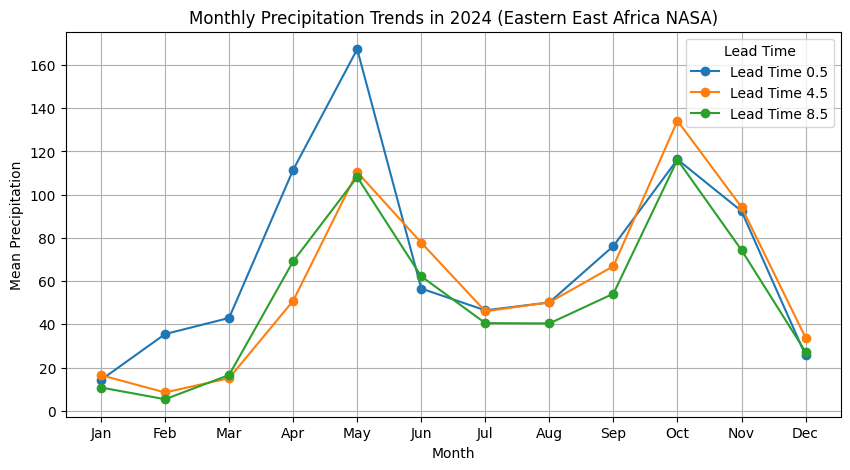

Wettest Months (Highest Precipitation) per Lead Time:
lead_time
0.5         5 (May)
4.5    10 (October)
8.5    10 (October)
dtype: object

Driest Months (Lowest Precipitation) per Lead Time:
lead_time
0.5     1 (January)
4.5    2 (February)
8.5    2 (February)
dtype: object


In [8]:
# lead time
lead_times = [0.5, 4.5, 8.5]
eea_nasa['time'] = pd.to_datetime(eea_nasa['time'])
eea_nasa['predicted_precip'] = eea_nasa['predicted_precip'] * 30

# 2024
eea_nasa_2024 = eea_nasa[eea_nasa['time'].dt.year == 2024].copy()

# lead time data / year
filtered_data = eea_nasa_2024[eea_nasa_2024['lead_time'].isin(lead_times)].copy()

#  extract month
filtered_data.loc[:, 'month'] = filtered_data['time'].dt.month

# mean precip for month for each lead time
monthly_precip = filtered_data.groupby(['lead_time', 'month'])['predicted_precip'].mean().unstack(level=0)

plt.figure(figsize=(10, 5))

for lead_time in lead_times:
    if lead_time in monthly_precip.columns:
        plt.plot(monthly_precip.index, monthly_precip[lead_time], marker='o', label=f'Lead Time {lead_time}')

plt.xlabel('Month')
plt.ylabel('Mean Precipitation')
plt.title('Monthly Precipitation Trends in 2024 (Eastern East Africa NASA)')
plt.xticks(ticks=range(1, 13), labels=[
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title="Lead Time")
plt.grid(True)
plt.show()

# wettest and driest month
wettest_months = monthly_precip.idxmax()
driest_months = monthly_precip.idxmin()

# map month numbers to names
month_names = {
    1: "January", 2: "February", 3: "March", 4: "April", 5: "May", 6: "June",
    7: "July", 8: "August", 9: "September", 10: "October", 11: "November", 12: "December"
}

# numerical months to named months
wettest_months_named = wettest_months.map(lambda x: f"{x} ({month_names[x]})")
driest_months_named = driest_months.map(lambda x: f"{x} ({month_names[x]})")

print("Wettest Months (Highest Precipitation) per Lead Time:")
print(wettest_months_named)
print("\nDriest Months (Lowest Precipitation) per Lead Time:")
print(driest_months_named)


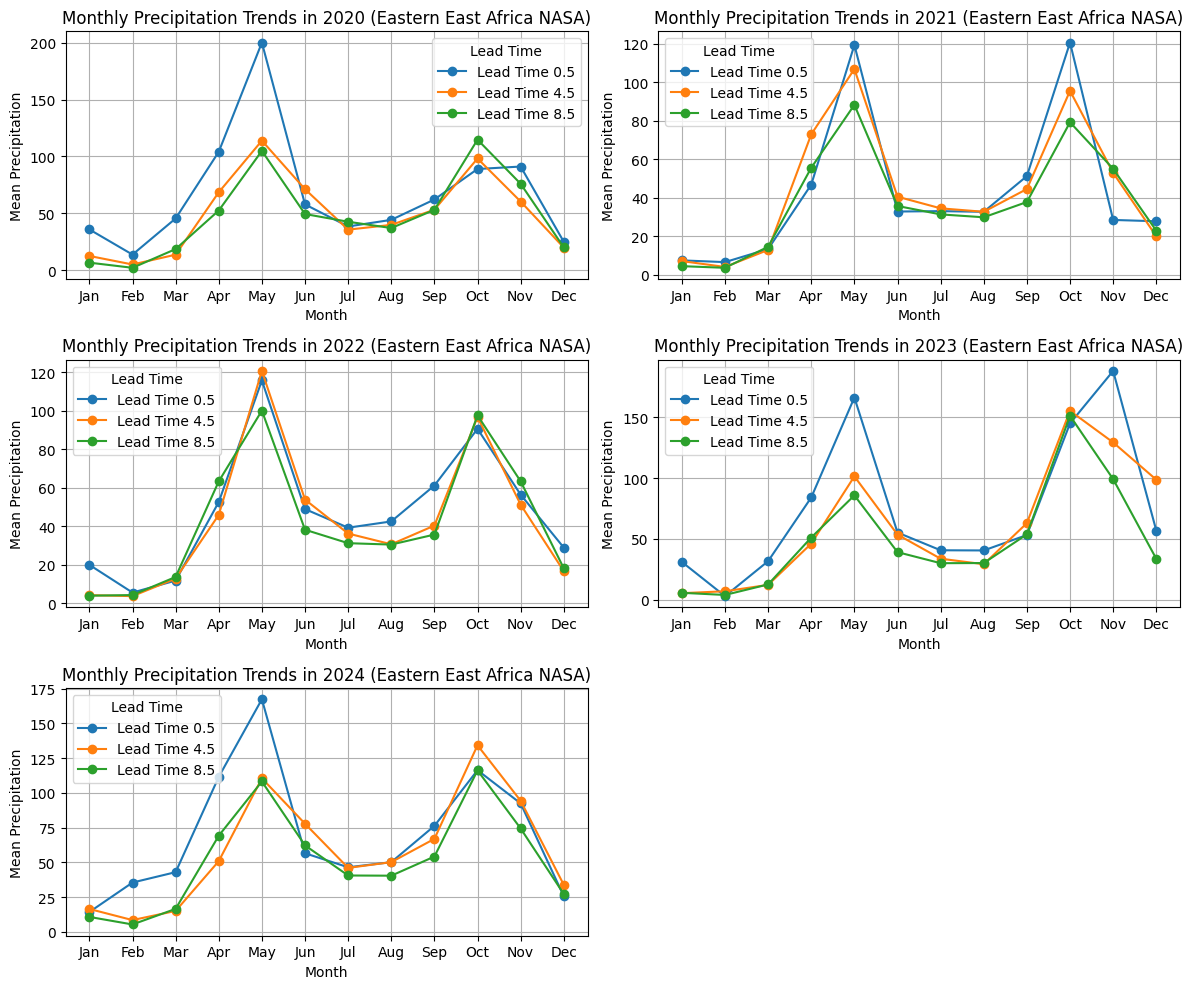

Comparison of Wettest Months (Highest Precipitation) across 2020-2024:
                   2020          2021     2022           2023          2024
lead_time                                                                  
0.5             5 (May)  10 (October)  5 (May)  11 (November)       5 (May)
4.5             5 (May)       5 (May)  5 (May)   10 (October)  10 (October)
8.5        10 (October)       5 (May)  5 (May)   10 (October)  10 (October)

Comparison of Driest Months (Lowest Precipitation) across 2020-2024:
                   2020          2021          2022          2023  \
lead_time                                                           
0.5        2 (February)  2 (February)  2 (February)  2 (February)   
4.5        2 (February)  2 (February)  2 (February)   1 (January)   
8.5        2 (February)  2 (February)   1 (January)  2 (February)   

                   2024  
lead_time                
0.5         1 (January)  
4.5        2 (February)  
8.5        2 (February)  


<ipython-input-9-e8b89739b2fa>:59: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  wettest_months_named_df = wettest_months_df.applymap(lambda x: f"{x} ({month_names[x]})" if pd.notna(x) else "N/A")
<ipython-input-9-e8b89739b2fa>:60: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  driest_months_named_df = driest_months_df.applymap(lambda x: f"{x} ({month_names[x]})" if pd.notna(x) else "N/A")


In [9]:
years = [2020, 2021, 2022, 2023, 2024]
lead_times = [0.5, 4.5, 8.5]

# dictionary to store wettest and driest months for each year
wettest_months_dict = {}
driest_months_dict = {}

# plots
plt.figure(figsize=(12, 10))

for i, year in enumerate(years, 1):
    # year data
    eea_nasa_year = eea_nasa[eea_nasa['time'].dt.year == year].copy()

    # lead times
    filtered_data = eea_nasa_year[eea_nasa_year['lead_time'].isin(lead_times)].copy()

    # month extract
    filtered_data.loc[:, 'month'] = filtered_data['time'].dt.month

    # Aggregate mean precipitation per month for each lead time
    monthly_precip = filtered_data.groupby(['lead_time', 'month'])['predicted_precip'].mean().unstack(level=0)

    # Create subplot for the year
    plt.subplot(3, 2, i)
    for lead_time in lead_times:
        if lead_time in monthly_precip.columns:
            plt.plot(monthly_precip.index, monthly_precip[lead_time], marker='o', linestyle='-', label=f'Lead Time {lead_time}')

    # Formatting the plot
    plt.xlabel('Month')
    plt.ylabel('Mean Precipitation')
    plt.title(f'Monthly Precipitation Trends in {year} (Eastern East Africa NASA)')
    plt.xticks(ticks=range(1, 13), labels=[
        'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    plt.legend(title="Lead Time")
    plt.grid(True)

    # Store wettest and driest months for the year
    wettest_months_dict[year] = monthly_precip.idxmax()
    driest_months_dict[year] = monthly_precip.idxmin()

# Adjust layout and show plots
plt.tight_layout()
plt.show()

# Convert dictionaries to DataFrames for better comparison
wettest_months_df = pd.DataFrame(wettest_months_dict)
driest_months_df = pd.DataFrame(driest_months_dict)

# map month numbers to names
month_names = {
    1: "January", 2: "February", 3: "March", 4: "April", 5: "May", 6: "June",
    7: "July", 8: "August", 9: "September", 10: "October", 11: "November", 12: "December"
}

# Convert numerical months to named months for both wettest and driest months
wettest_months_named_df = wettest_months_df.applymap(lambda x: f"{x} ({month_names[x]})" if pd.notna(x) else "N/A")
driest_months_named_df = driest_months_df.applymap(lambda x: f"{x} ({month_names[x]})" if pd.notna(x) else "N/A")

# Print results with month names for comparison
print("Comparison of Wettest Months (Highest Precipitation) across 2020-2024:")
print(wettest_months_named_df)
print("\nComparison of Driest Months (Lowest Precipitation) across 2020-2024:")
print(driest_months_named_df)

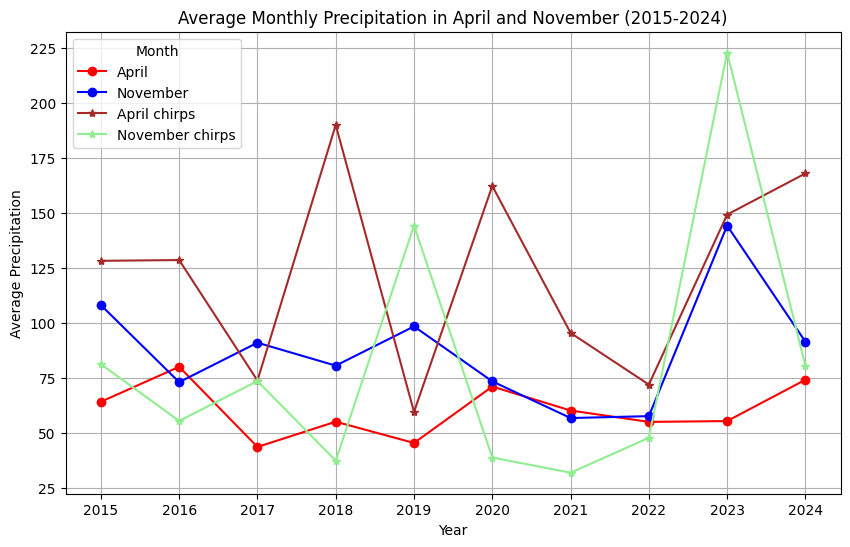

In [10]:
years = [2015, 2016,2017,2018, 2019, 2020, 2021, 2022, 2023, 2024]
months_of_interest = [4, 11]  # April and November

# Filter data for the selected years and months
filtered_data = eea_nasa[eea_nasa['time'].dt.year.isin(years) & eea_nasa['time'].dt.month.isin(months_of_interest)].copy()

# Extract year and month
filtered_data['year'] = filtered_data['time'].dt.year
filtered_data['month'] = filtered_data['time'].dt.month

# Compute average precipitation per month for each year
monthly_avg_precip = filtered_data.groupby(['year', 'month'])['predicted_precip'].mean().unstack(level=1)
monthly_avg_precip_act = filtered_data.groupby(['year', 'month'])['precip'].mean().unstack(level=1)

# Plot the results
plt.figure(figsize=(10, 6))

# predicted
plt.plot(monthly_avg_precip.index, monthly_avg_precip[4], marker='o', linestyle='-', label='April', color='red')
plt.plot(monthly_avg_precip.index, monthly_avg_precip[11], marker='o', linestyle='-', label='November', color='blue')

# actual
plt.plot(monthly_avg_precip_act.index, monthly_avg_precip_act[4], marker='*', linestyle='-', label='April chirps', color='brown')
plt.plot(monthly_avg_precip_act.index, monthly_avg_precip_act[11], marker='*', linestyle='-', label='November chirps', color='lightgreen')

plt.xlabel('Year')
plt.ylabel('Average Precipitation')
plt.title('Average Monthly Precipitation in April and November (2015-2024)')
plt.xticks(years)
plt.legend(title="Month")
plt.grid(True)

plt.show()


EASTERN EAST AFRICA GFDL

In [11]:
eea_gfdl_path = '/content/drive/MyDrive/capstone_data/netCDF/eastern_east_africa_GFDL_merged.nc'
eea_gfdl = xr.open_dataset(eea_gfdl_path)

eea_gfdl_slice = eea_gfdl["precip"]
eea_gfdl = eea_gfdl.to_dataframe().reset_index()

eea_gfdl

,lead_time,time,M,latitude,longitude,predicted_precip,precip
0,0.5,1991-01-01,1.0,-3.5,38.0,1.304757,18.434658
1,0.5,1991-01-01,1.0,-3.5,38.5,1.304757,21.333597
2,0.5,1991-01-01,1.0,-3.5,39.0,0.819409,17.430561
3,0.5,1991-01-01,1.0,-3.5,39.5,0.819409,11.300217
4,0.5,1991-01-01,1.0,-3.5,40.0,NaN,NaN
...,...,...,...,...,...,...,...
84602875,11.5,2024-12-01,30.0,8.0,47.5,0.212323,2.742029
84602876,11.5,2024-12-01,30.0,8.0,48.0,0.250369,0.612805
84602877,11.5,2024-12-01,30.0,8.0,48.5,0.250369,0.271429
84602878,11.5,2024-12-01,30.0,8.0,49.0,0.114503,0.280411


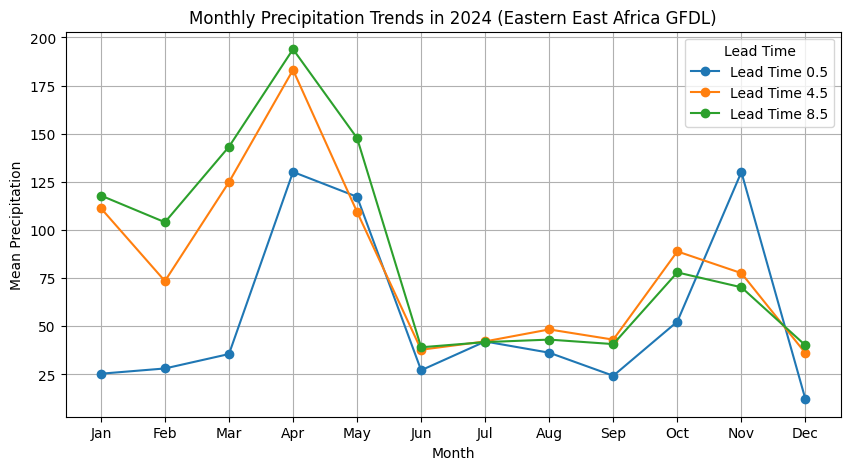

Wettest Months (Highest Precipitation) per Lead Time:
lead_time
0.5    4 (April)
4.5    4 (April)
8.5    4 (April)
dtype: object

Driest Months (Lowest Precipitation) per Lead Time:
lead_time
0.5    12 (December)
4.5    12 (December)
8.5         6 (June)
dtype: object


In [12]:
# lead time
lead_times = [0.5, 4.5, 8.5]

eea_gfdl['time'] = pd.to_datetime(eea_gfdl['time'])
eea_gfdl['predicted_precip'] = eea_gfdl['predicted_precip'] * 30

# 2024
eea_gfdl_2024 = eea_gfdl[eea_gfdl['time'].dt.year == 2024].copy()

# lead time data / year
filtered_data = eea_gfdl_2024[eea_gfdl_2024['lead_time'].isin(lead_times)].copy()

#  extract month
filtered_data.loc[:, 'month'] = filtered_data['time'].dt.month

# mean precip for month for each lead time
monthly_precip = filtered_data.groupby(['lead_time', 'month'])['predicted_precip'].mean().unstack(level=0)

plt.figure(figsize=(10, 5))

for lead_time in lead_times:
    if lead_time in monthly_precip.columns:
        plt.plot(monthly_precip.index, monthly_precip[lead_time], marker='o', label=f'Lead Time {lead_time}')

plt.xlabel('Month')
plt.ylabel('Mean Precipitation')
plt.title('Monthly Precipitation Trends in 2024 (Eastern East Africa GFDL)')
plt.xticks(ticks=range(1, 13), labels=[
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title="Lead Time")
plt.grid(True)
plt.show()

# wettest and driest month
wettest_months = monthly_precip.idxmax()
driest_months = monthly_precip.idxmin()

# map month numbers to names
month_names = {
    1: "January", 2: "February", 3: "March", 4: "April", 5: "May", 6: "June",
    7: "July", 8: "August", 9: "September", 10: "October", 11: "November", 12: "December"
}

# numerical months to named months
wettest_months_named = wettest_months.map(lambda x: f"{x} ({month_names[x]})")
driest_months_named = driest_months.map(lambda x: f"{x} ({month_names[x]})")

print("Wettest Months (Highest Precipitation) per Lead Time:")
print(wettest_months_named)
print("\nDriest Months (Lowest Precipitation) per Lead Time:")
print(driest_months_named)


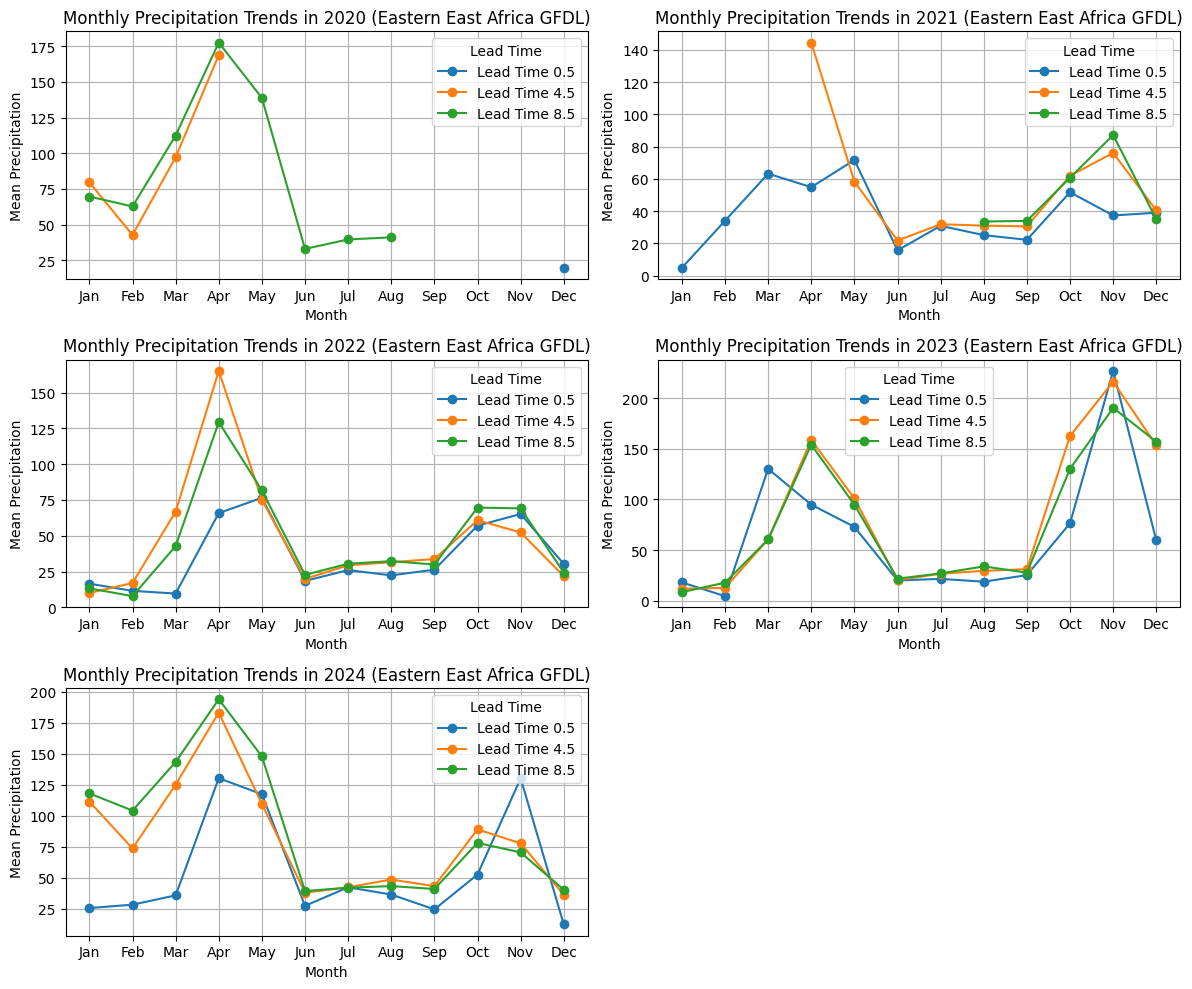

Comparison of Wettest Months (Highest Precipitation) across 2020-2024:
                    2020           2021       2022           2023       2024
lead_time                                                                   
0.5        12 (December)        5 (May)    5 (May)  11 (November)  4 (April)
4.5            4 (April)      4 (April)  4 (April)  11 (November)  4 (April)
8.5            4 (April)  11 (November)  4 (April)  11 (November)  4 (April)

Comparison of Driest Months (Lowest Precipitation) across 2020-2024:
                    2020         2021          2022          2023  \
lead_time                                                           
0.5        12 (December)  1 (January)     3 (March)  2 (February)   
4.5         2 (February)     6 (June)   1 (January)   1 (January)   
8.5             6 (June)   8 (August)  2 (February)   1 (January)   

                    2024  
lead_time                 
0.5        12 (December)  
4.5        12 (December)  
8.5             6 (J

<ipython-input-13-6d389589475c>:58: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  wettest_months_named_df = wettest_months_df.applymap(lambda x: f"{x} ({month_names[x]})" if pd.notna(x) else "N/A")
<ipython-input-13-6d389589475c>:59: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  driest_months_named_df = driest_months_df.applymap(lambda x: f"{x} ({month_names[x]})" if pd.notna(x) else "N/A")


In [13]:
years = [2020, 2021, 2022, 2023, 2024]

# dictionary to store wettest and driest months for each year
wettest_months_dict = {}
driest_months_dict = {}

# plots
plt.figure(figsize=(12, 10))

for i, year in enumerate(years, 1):
    # year data
    eea_gfdl_year = eea_gfdl[eea_gfdl['time'].dt.year == year].copy()

    # lead times
    filtered_data = eea_gfdl_year[eea_gfdl_year['lead_time'].isin(lead_times)].copy()

    # month extract
    filtered_data.loc[:, 'month'] = filtered_data['time'].dt.month

    # Aggregate mean precipitation per month for each lead time
    monthly_precip = filtered_data.groupby(['lead_time', 'month'])['predicted_precip'].mean().unstack(level=0)

    # Create subplot for the year
    plt.subplot(3, 2, i)
    for lead_time in lead_times:
        if lead_time in monthly_precip.columns:
            plt.plot(monthly_precip.index, monthly_precip[lead_time], marker='o', linestyle='-', label=f'Lead Time {lead_time}')

    # Formatting the plot
    plt.xlabel('Month')
    plt.ylabel('Mean Precipitation')
    plt.title(f'Monthly Precipitation Trends in {year} (Eastern East Africa GFDL)')
    plt.xticks(ticks=range(1, 13), labels=[
        'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    plt.legend(title="Lead Time")
    plt.grid(True)

    # Store wettest and driest months for the year
    wettest_months_dict[year] = monthly_precip.idxmax()
    driest_months_dict[year] = monthly_precip.idxmin()

# Adjust layout and show plots
plt.tight_layout()
plt.show()

# Convert dictionaries to DataFrames for better comparison
wettest_months_df = pd.DataFrame(wettest_months_dict)
driest_months_df = pd.DataFrame(driest_months_dict)

# map month numbers to names
month_names = {
    1: "January", 2: "February", 3: "March", 4: "April", 5: "May", 6: "June",
    7: "July", 8: "August", 9: "September", 10: "October", 11: "November", 12: "December"
}

# Convert numerical months to named months for both wettest and driest months
wettest_months_named_df = wettest_months_df.applymap(lambda x: f"{x} ({month_names[x]})" if pd.notna(x) else "N/A")
driest_months_named_df = driest_months_df.applymap(lambda x: f"{x} ({month_names[x]})" if pd.notna(x) else "N/A")

# Print results with month names for comparison
print("Comparison of Wettest Months (Highest Precipitation) across 2020-2024:")
print(wettest_months_named_df)
print("\nComparison of Driest Months (Lowest Precipitation) across 2020-2024:")
print(driest_months_named_df)

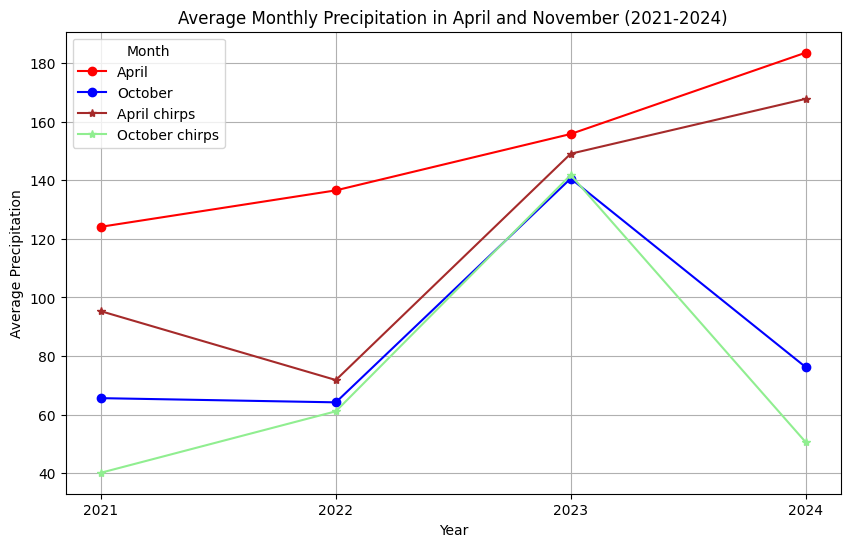

In [14]:
years = [2021, 2022, 2023, 2024]
months_of_interest = [4, 10]  # April and November

# Filter data for the selected years and months
filtered_data = eea_gfdl[eea_gfdl['time'].dt.year.isin(years) & eea_gfdl['time'].dt.month.isin(months_of_interest)].copy()

# Extract year and month
filtered_data['year'] = filtered_data['time'].dt.year
filtered_data['month'] = filtered_data['time'].dt.month

# Compute average precipitation per month for each year
monthly_avg_precip = filtered_data.groupby(['year', 'month'])['predicted_precip'].mean().unstack(level=1)
monthly_avg_precip_act = filtered_data.groupby(['year', 'month'])['precip'].mean().unstack(level=1)

# Plot the results
plt.figure(figsize=(10, 6))

# predicted
plt.plot(monthly_avg_precip.index, monthly_avg_precip[4], marker='o', linestyle='-', label='April', color='red')
plt.plot(monthly_avg_precip.index, monthly_avg_precip[10], marker='o', linestyle='-', label='October', color='blue')

# actual
plt.plot(monthly_avg_precip_act.index, monthly_avg_precip_act[4], marker='*', linestyle='-', label='April chirps', color='brown')
plt.plot(monthly_avg_precip_act.index, monthly_avg_precip_act[10], marker='*', linestyle='-', label='October chirps', color='lightgreen')

plt.xlabel('Year')
plt.ylabel('Average Precipitation')
plt.title('Average Monthly Precipitation in April and November (2021-2024)')
plt.xticks(years)
plt.legend(title="Month")
plt.grid(True)

plt.show()
